<h2>Titanic competition

This notebook will take you through the steps needed to train a baseline Gradient Boosted Trees Model using TensorFlow Decision Forests and creating a submission on the Titanic competition.

This notebook shows:

1. How to do some basic pre-processing. For example, the passenger names will be tokenized, and ticket names will be splitted in parts.
2. How to train a Gradient Boosted Trees (GBT) with default parameters
3. How to train a GBT with improved default parameters
4. How to tune the parameters of a GBTs
5. How to train and ensemble many GBTs

This project predicts passenger survival on the Titanic using machine learning models.

I started with exploratory data analysis to identify key survival patterns and then built two models:
- Logistic Regression as a baseline
- Random Forest as the final model

The analysis showed that gender, passenger class, fare, and age were among the strongest predictors of survival. Female passengers and first-class travelers had significantly higher survival rates.

The final model demonstrated solid classification performance and was evaluated using accuracy, ROC AUC, confusion matrix, and feature importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Train shape:", train_df.shape)
print("\nMissing values:")
print(train_df.isnull().sum().sort_values(ascending=False))

Train shape: (891, 12)

Missing values:
Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64


In [4]:
survival_rate = train_df["Survived"].mean()
print(f"Overall survival rate: {survival_rate:.2%}")

Overall survival rate: 38.38%


In [5]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target = "Survived"

X = train_df[features]
y = train_df[target]
X_test_kaggle = test_df[features]

In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
numeric_features = ["Age", "Fare", "SibSp", "Parch", "Pclass"]
categorical_features = ["Sex", "Embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [8]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)

y_pred_logreg = logreg_pipeline.predict(X_valid)
y_proba_logreg = logreg_pipeline.predict_proba(X_valid)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_valid, y_pred_logreg))
print("Logistic Regression ROC AUC:", roc_auc_score(y_valid, y_proba_logreg))

Logistic Regression Accuracy: 0.8044692737430168
Logistic Regression ROC AUC: 0.8436100131752305


In [9]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_valid)
y_proba_rf = rf_pipeline.predict_proba(X_valid)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_valid, y_pred_rf))
print("Random Forest ROC AUC:", roc_auc_score(y_valid, y_proba_rf))

Random Forest Accuracy: 0.8100558659217877
Random Forest ROC AUC: 0.8472990777338604


In [10]:
print("Random Forest Classification Report:\n")
print(classification_report(y_valid, y_pred_rf))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.94      0.86       110
           1       0.86      0.61      0.71        69

    accuracy                           0.81       179
   macro avg       0.82      0.77      0.79       179
weighted avg       0.82      0.81      0.80       179



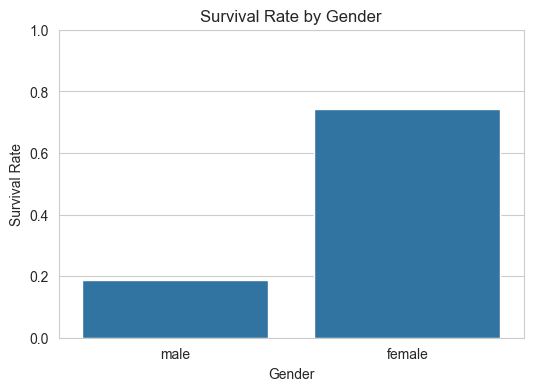

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=train_df, x="Sex", y="Survived", estimator=np.mean, errorbar=None)
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xlabel("Gender")
plt.ylim(0, 1)
plt.show()
#Female passengers had a significantly higher survival rate (~74%) compared to males (~19%)

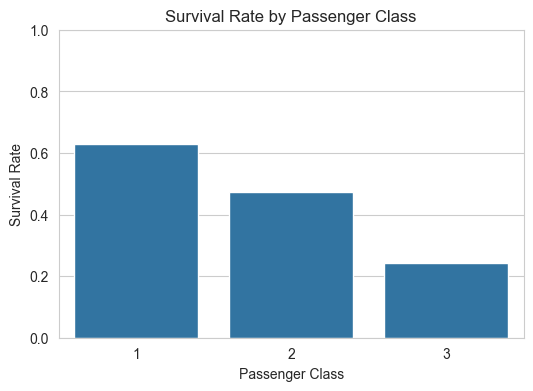

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=train_df, x = "Pclass", y = "Survived", estimator=np.mean, errorbar=None)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.ylim(0, 1)
plt.show()
#First-class passengers had the highest survival rate, while third-class passengers had the lowest.

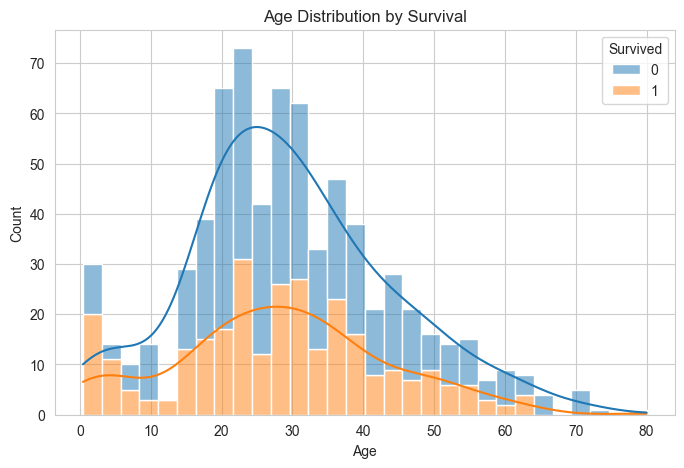

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(data=train_df, x="Age", hue="Survived", bins=30, kde=True, multiple="stack")
plt.title("Age Distribution by Survival")
plt.show()
#Younger passengers show slightly higher survival rates, although age is not the strongest predictor.

<h4>Fare varies significantly across passenger classes. First-class passengers paid much higher fares compared to second and third class. This supports the idea that socio-economic status played a major role in survival outcomes.

We saw earlier that first-class passengers had higher survival rates. This chart shows that they also paid significantly higher fares, suggesting that wealth and access to resources influenced survival.

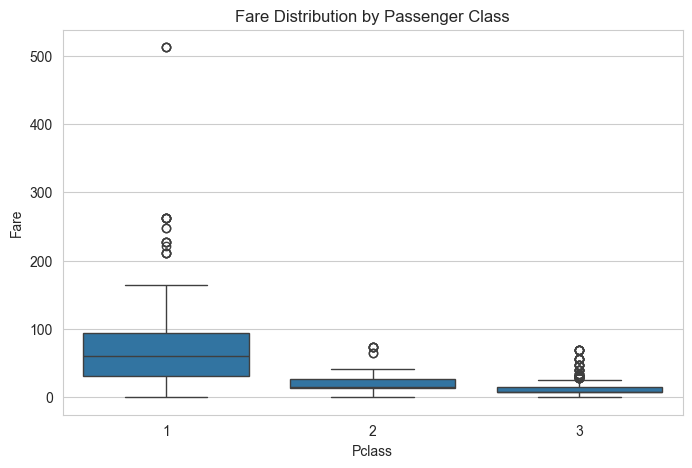

In [43]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train_df, x="Pclass", y="Fare")
plt.title("Fare Distribution by Passenger Class")
plt.show()
#Higher passenger classes paid significantly higher fares, which is consistent with their higher survival rates.

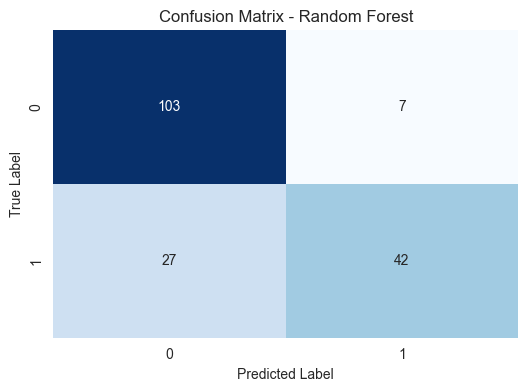

In [ ]:
cm = confusion_matrix(y_valid, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
#The model performs well in identifying non-survivors, but has lower recall for survivors.

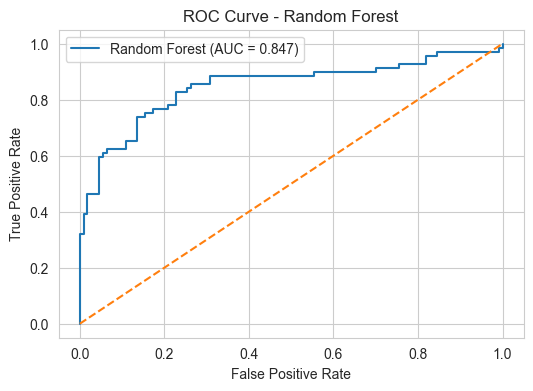

In [ ]:
fpr, tpr, thresholds = roc_curve(y_valid, y_proba_rf)
auc_score = roc_auc_score(y_valid, y_proba_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
#The model demonstrates strong classification performance with an AUC of ~0.85.

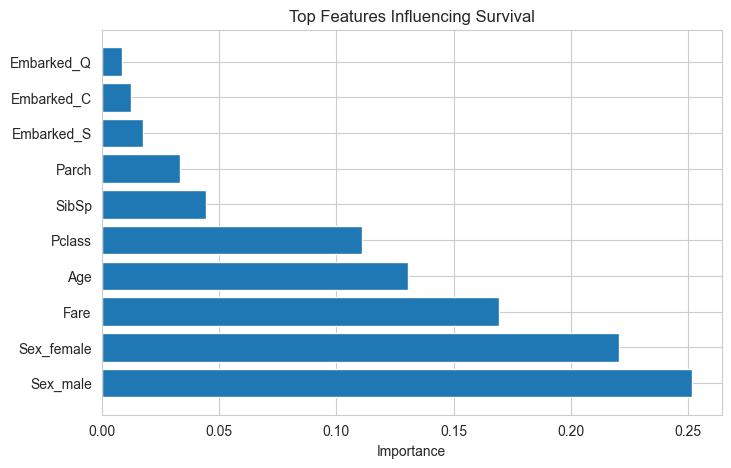

In [28]:
# get feature names after preprocessing
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(encoded_cat_features)

importances = rf_pipeline.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(fi_df["Feature"][::-1], fi_df["Importance"][::-1])
plt.title("Top Features Influencing Survival")
plt.xlabel("Importance")
plt.show()

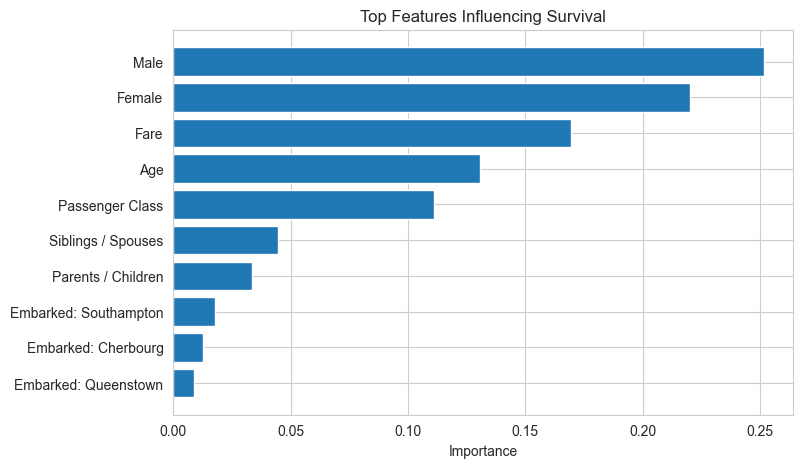

In [ ]:
feature_name_map = {
    "Pclass": "Passenger Class",
    "Age": "Age",
    "Fare": "Fare",
    "SibSp": "Siblings / Spouses",
    "Parch": "Parents / Children",
    "Sex_female": "Female",
    "Sex_male": "Male",
    "Embarked_C": "Embarked: Cherbourg",
    "Embarked_Q": "Embarked: Queenstown",
    "Embarked_S": "Embarked: Southampton"
}

fi_df["Feature"] = fi_df["Feature"].map(lambda x: feature_name_map.get(x, x))

plt.figure(figsize=(8, 5))
plt.barh(fi_df["Feature"][::-1], fi_df["Importance"][::-1])
plt.title("Top Features Influencing Survival")
plt.xlabel("Importance")
plt.show()
#Gender, fare, and age were the most influential features in predicting survival.

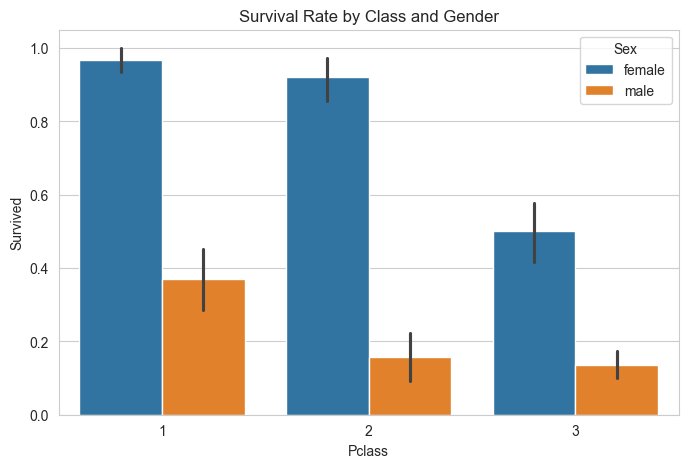

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(data=train_df, x="Pclass", y="Survived", hue="Sex")
plt.title("Survival Rate by Class and Gender")
plt.show()
#Women in all classes had higher survival rates, especially in first class.